In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
import pandas as pd
from utils import load_and_clean_data, calculate_momentum_scores, run_model_experiment

# 1. LOAD AND PROCESS
file_path = 'companies_cleaned.csv'
df_train_raw, df_full = load_and_clean_data(file_path)
df_train, yearly_word_scores, yearly_word_freq = calculate_momentum_scores(df_train_raw, df_full)

# 2. TRAIN MODELS
rf_aug, xgb_aug, X_aug_test, y_test, metrics = run_model_experiment(df_train)

# 3. PRINT F1 SCORES
print("\n" + "="*50)
print("     COMPARATIVE MODEL RESULTS (F1 SCORE)")
print("="*50)
print("RANDOM FOREST:")
print(f"  Baseline:   {metrics['Random Forest']['Baseline']:.4f}")
print(f"  Augmented:  {metrics['Random Forest']['Augmented']:.4f}")
print("\nXGBOOST:")
print(f"  Baseline:   {metrics['XGBoost']['Baseline']:.4f}")
print(f"  Augmented:  {metrics['XGBoost']['Augmented']:.4f}")
print("="*50)

/Users/nehiraltuntas/Desktop/success_prediction_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading and Cleaning Data...
Pre-processing text: Combining, Cleaning, and Lemmatizing (Fast Batch Mode)...
Training Models...
Models Trained Successfully!

     COMPARATIVE MODEL RESULTS (F1 SCORE)
RANDOM FOREST:
  Baseline:   0.8173
  Augmented:  0.8463

XGBOOST:
  Baseline:   0.8256
  Augmented:  0.8404


In [2]:
# 4. TRUTH TABLE
score_names = {0: '0 - Niche Areas', 1: '1 - Established Trend', 2: '2 - Strong Signal', 3: '3 - Weak Signal (Pioneer)'}

truth_table = df_train.groupby('Market_Signal_Score').agg(
    Total_Startups=('Target', 'count'),
    Successful_Exits=('Target', 'sum'),
    Exit_Rate=('Target', 'mean')
).reset_index()

truth_table['Market Category'] = truth_table['Market_Signal_Score'].map(score_names)
truth_table['Exit_Rate'] = (truth_table['Exit_Rate'] * 100).round(2).astype(str) + '%'

print("\n--- MARKET SIGNAL TRUTH TABLE ---")
display(truth_table[['Market Category', 'Total_Startups', 'Successful_Exits', 'Exit_Rate']])

# 5. SCORE 3 KEYWORDS
#analysis_year = df_full['batch_year'].max()
analysis_year = 2010
print(f"\n--- Top 'Score 3' (Weak Signal) Keywords for {analysis_year} ---")

current_scores = yearly_word_scores.get(analysis_year, {})
current_freqs = yearly_word_freq.get(analysis_year, {})

word_data = [{'Word': w, 'Score': s, 'TF-IDF': current_freqs.get(w, 0)} for w, s in current_scores.items() if s == 3]
df_words = pd.DataFrame(word_data)

if not df_words.empty:
    df_phrases = df_words[df_words['Word'].str.contains(" ")]
    display(df_phrases.sort_values(by='TF-IDF', ascending=False).head(15).reset_index(drop=True))
    
else:
    print("No Weak Signals detected for this year.")


--- MARKET SIGNAL TRUTH TABLE ---


,Market Category,Total_Startups,Successful_Exits,Exit_Rate
0,0 - Niche Areas,2612,2276,87.14%
1,1 - Established Trend,394,273,69.29%
2,2 - Strong Signal,711,381,53.59%
3,3 - Weak Signal (Pioneer),1931,983,50.91%



--- Top 'Score 3' (Weak Signal) Keywords for 2010 ---


,Word,Score,TF-IDF
0,group buying,3,0.002190
1,media marketing,3,0.002146
2,medium social,3,0.001977
3,mobile iphone,3,0.001940
4,social gaming,3,0.001890
5,twitter facebook,3,0.001863
6,social mobile,3,0.001817
7,online store,3,0.001736
8,free online,3,0.001658
9,online shopping,3,0.001602


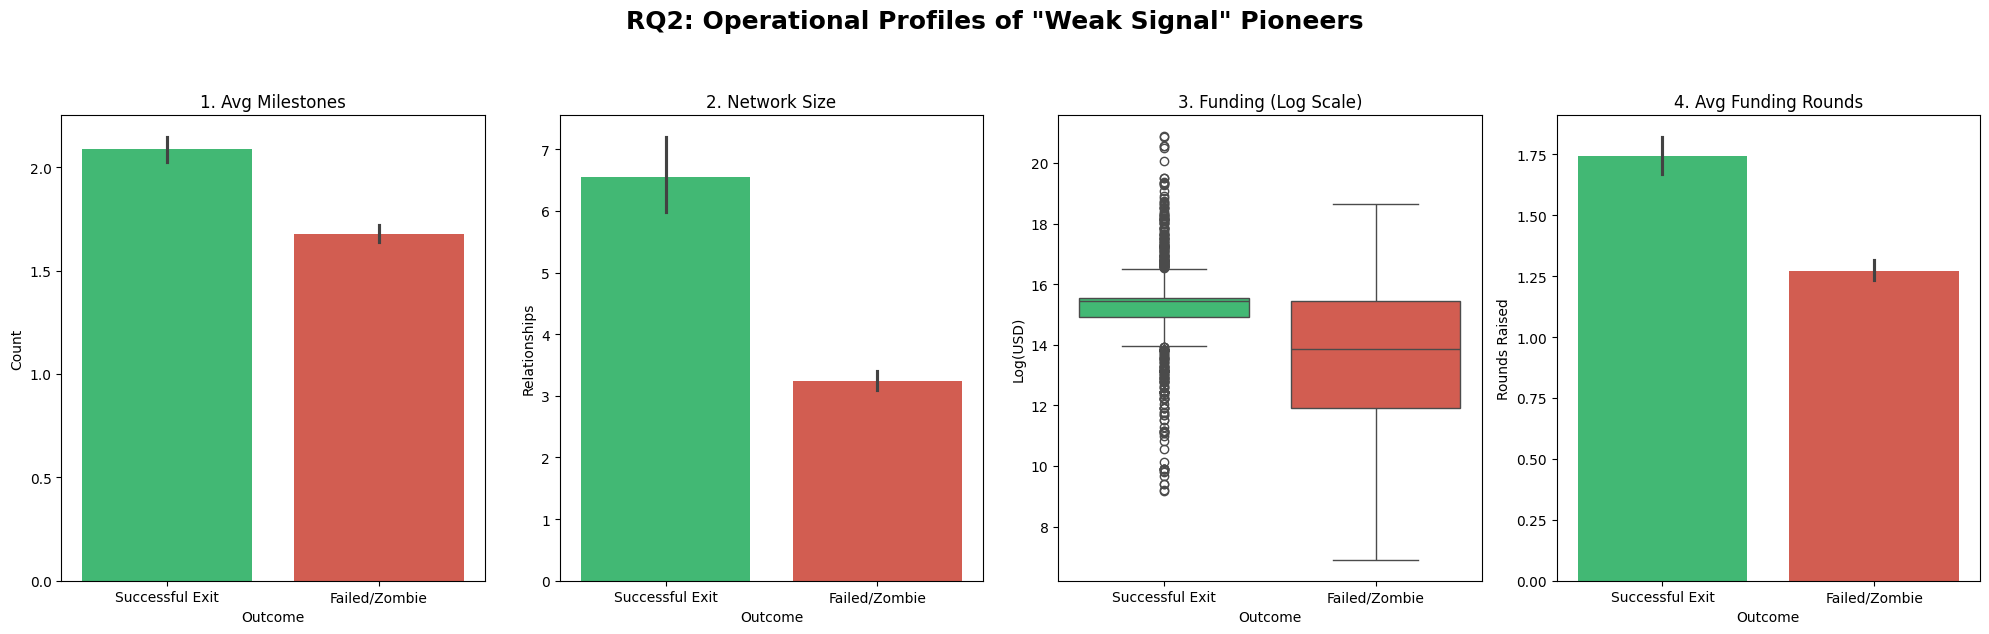

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Isolate ONLY the pioneers (Market Score = 3)
df_weak = df_train[df_train['Market_Signal_Score'] == 3].copy()
df_weak['Outcome'] = df_weak['Target'].map({1: 'Successful Exit', 0: 'Failed/Zombie'})

# Log transform funding
df_weak['log_funding'] = np.log1p(df_weak['funding_total_usd'])

#  1x4 grid
fig, axes = plt.subplots(1, 4, figsize=(20, 6)) 
fig.suptitle('RQ2: Operational Profiles of "Weak Signal" Pioneers', fontsize=18, fontweight='bold', y=1.05)

custom_palette = {'Failed/Zombie': '#e74c3c', 'Successful Exit': '#2ecc71'}

# 1. Milestones 
sns.barplot(data=df_weak, x='Outcome', y='milestones', ax=axes[0], palette=custom_palette)
axes[0].set_title('1. Avg Milestones')
axes[0].set_ylabel('Count')

# 2. Relationships 
sns.barplot(data=df_weak, x='Outcome', y='relationships', ax=axes[1], palette=custom_palette)
axes[1].set_title('2. Network Size')
axes[1].set_ylabel('Relationships')

# 3. Total Funding 
sns.boxplot(data=df_weak, x='Outcome', y='log_funding', ax=axes[2], palette=custom_palette)
axes[2].set_title('3. Funding (Log Scale)')
axes[2].set_ylabel('Log(USD)')

# 4. Funding Rounds 
sns.barplot(data=df_weak, x='Outcome', y='funding_rounds', ax=axes[3], palette=custom_palette)
axes[3].set_title('4. Avg Funding Rounds')
axes[3].set_ylabel('Rounds Raised')

plt.tight_layout()
plt.show()

Generating SHAP values...


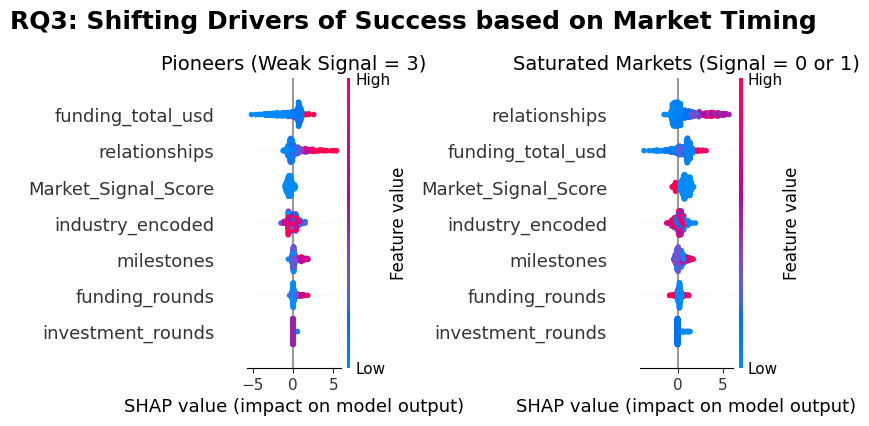

In [5]:
# RQ3: How do the drivers of success change depending on market timing?

print("Generating SHAP values...")
explainer = shap.TreeExplainer(xgb_aug)
shap_values = explainer.shap_values(X_aug_test)

mask_pioneer = X_aug_test['Market_Signal_Score'] == 3
mask_saturated = X_aug_test['Market_Signal_Score'] <= 1

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("RQ3: Shifting Drivers of Success based on Market Timing", fontsize=18, fontweight='bold')

plt.subplot(1, 2, 1)
plt.title("Pioneers (Weak Signal = 3)", fontsize=14)
shap.summary_plot(shap_values[mask_pioneer], X_aug_test[mask_pioneer], plot_type="dot", show=False)

plt.subplot(1, 2, 2)
plt.title("Saturated Markets (Signal = 0 or 1)", fontsize=14)
shap.summary_plot(shap_values[mask_saturated], X_aug_test[mask_saturated], plot_type="dot", show=False)

plt.tight_layout()
plt.show()

Decoding industries and generating Cross-Industry SHAP comparison...



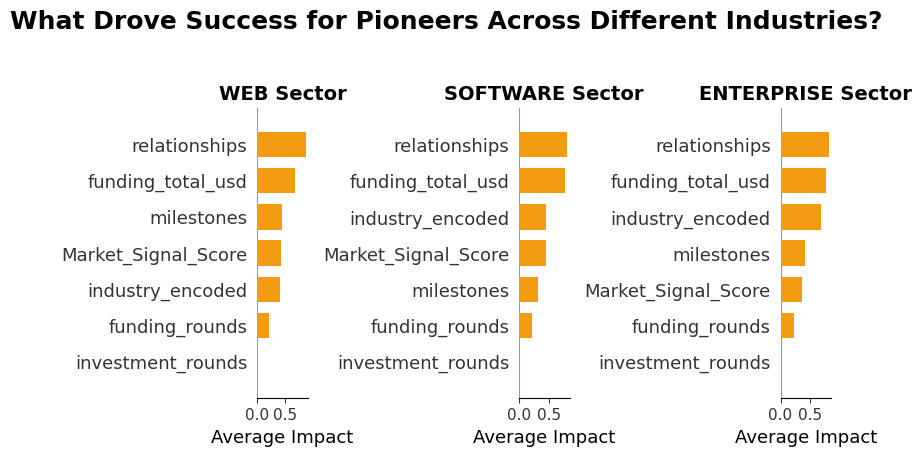

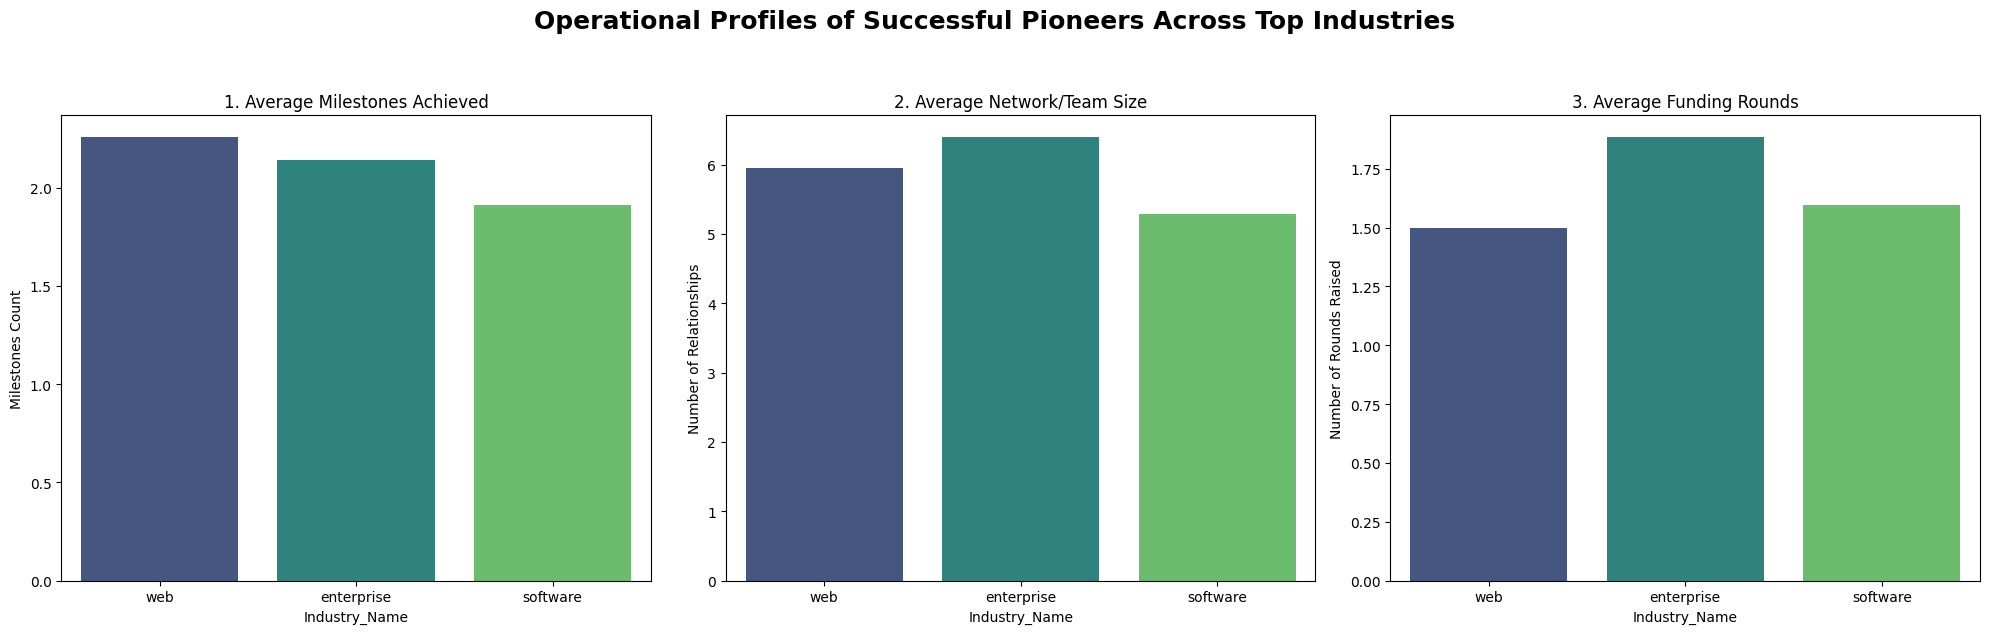

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pandas as pd
import numpy as np

print("Decoding industries and generating Cross-Industry SHAP comparison...\n")

# 1. Create a "Decoder Ring" to turn numbers back into industry names
industry_map = dict(zip(df_train['industry_encoded'], df_train['category_code'].fillna('Unknown')))

# 2. Isolate Successful Pioneers
expected_cols = xgb_aug.feature_names_in_ 
X_full = df_train[expected_cols]
y_full = df_train['Target']

# Create the mask for Successful Pioneers
success_pioneer_mask = (X_full['Market_Signal_Score'] == 3) & (y_full == 1)
X_success_pioneers = X_full[success_pioneer_mask].copy()

# 3. Find the Top 3 Industries among these successful pioneers
top_industries = X_success_pioneers['industry_encoded'].value_counts().head(3).index.tolist()

# 4. Set up the SHAP
shap.initjs()
explainer = shap.TreeExplainer(xgb_aug)

# 5. Plotting Side-by-Side SHAP Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('What Drove Success for Pioneers Across Different Industries?', fontsize=18, fontweight='bold', y=1.05)

for i, ind_code in enumerate(top_industries):
    ind_name = industry_map.get(ind_code, "Unknown").upper()
    
    # Filter for this specific industry
    X_ind = X_success_pioneers[X_success_pioneers['industry_encoded'] == ind_code]
    
    # Calculate SHAP values
    shap_values_ind = explainer.shap_values(X_ind)
    
    # Plot on the corresponding subplot
    plt.subplot(1, 3, i+1)
    plt.title(f"{ind_name} Sector", fontweight='bold', fontsize=14)
    
    # SHAP summary plot as a bar chart
    shap.summary_plot(shap_values_ind, X_ind, plot_type="bar", show=False, color="#f39c12")
    
    # Clean up x-axis label for clarity
    plt.xlabel("Average Impact")

plt.tight_layout()
plt.show()



# 1. Isolate Successful Pioneers in the Top 3 Industries
df_top_inds = df_train[(df_train['Market_Signal_Score'] == 3) & 
                       (df_train['Target'] == 1) & 
                       (df_train['industry_encoded'].isin(top_industries))].copy()

# 2. Map industry numbers back to readable names
df_top_inds['Industry_Name'] = df_top_inds['industry_encoded'].map(industry_map)

# 3. Log transform funding so billion-dollar unicorns don't ruin the scale
df_top_inds['log_funding'] = np.log1p(df_top_inds['funding_total_usd'])

# Initialize 1 row, 3 columns to match your 3 metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Operational Profiles of Successful Pioneers Across Top Industries', fontsize=18, fontweight='bold', y=1.05)

# 1. Milestones 
sns.barplot(data=df_top_inds, x='Industry_Name', y='milestones', ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('1. Average Milestones Achieved')
axes[0].set_ylabel('Milestones Count')

# 2. Relationships 
sns.barplot(data=df_top_inds, x='Industry_Name', y='relationships', ax=axes[1], palette='viridis', errorbar=None)
axes[1].set_title('2. Average Network/Team Size')
axes[1].set_ylabel('Number of Relationships')

# 3. Funding Rounds
sns.barplot(data=df_top_inds, x='Industry_Name', y='funding_rounds', ax=axes[2], palette='viridis', errorbar=None)
axes[2].set_title('3. Average Funding Rounds')
axes[2].set_ylabel('Number of Rounds Raised')

plt.tight_layout()
plt.show()